# Feature Engineering & Data Preparation for Machine Learning

## Define the Machine Learning Problem & Target Variable

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/customer_churn_clean.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
target_column = "Churn"

print("Target variable:", target_column)
print("\nTarget values:")
print(df[target_column].value_counts())

Target variable: Churn

Target values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [4]:
target_distribution = (
    df[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_distribution)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [5]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df["Churn"].value_counts())
display(df[["Churn"]].head())

Churn
0    5174
1    1869
Name: count, dtype: int64


,Churn
0,0
1,0
2,1
3,0
4,1


In [6]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7043, 20)
Target shape: (7043,)


In [7]:
print("Missing target values:", y.isna().sum())

Missing target values: 0


In [8]:
print("Machine Learning Problem")
print("------------------------")
print("Problem Type: Binary Classification")
print("Target Variable:", target_column)
print("Negative Class: 0 = No Churn")
print("Positive Class: 1 = Churn")
print("Number of Features:", X.shape[1])
print("Number of Customers:", X.shape[0])
print("Missing Target Values:", y.isna().sum())

Machine Learning Problem
------------------------
Problem Type: Binary Classification
Target Variable: Churn
Negative Class: 0 = No Churn
Positive Class: 1 = Churn
Number of Features: 20
Number of Customers: 7043
Missing Target Values: 0


## ML Problem Definition

### Objective
Define the machine-learning problem for predicting customer churn.

### Target
`Churn`

- 0 → No Churn
- 1 → Churn

### Business Objective
Predict customers likely to churn so that retention actions can be
considered before customers leave.



## Feature Selection

In [9]:
print("Current features:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

Current features:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Number of features: 20


In [10]:
X = X.drop(columns=["customerID"])

print("Features after removing customerID:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

Features after removing customerID:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Number of features: 19


In [11]:
print("Feature data types:")
display(X.dtypes)

Feature data types:


gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [12]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 4
Number of categorical features: 15


In [13]:
duplicate_columns = X.columns[X.T.duplicated()].tolist()

print("Duplicate columns:", duplicate_columns)

Duplicate columns: []


In [14]:
feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str).values,
    "Feature Type": [
        "Numerical" if column in numerical_features else "Categorical"
        for column in X.columns
    ]
})

display(feature_summary)

,Feature,Data Type,Feature Type
0,gender,str,Categorical
1,SeniorCitizen,int64,Numerical
2,Partner,str,Categorical
3,Dependents,str,Categorical
4,tenure,int64,Numerical
5,PhoneService,str,Categorical
6,MultipleLines,str,Categorical
7,InternetService,str,Categorical
8,OnlineSecurity,str,Categorical
9,OnlineBackup,str,Categorical


In [15]:
print("Final ML dataset")
print("----------------")
print("Customers:", X.shape[0])
print("Features:", X.shape[1])
print("Target observations:", y.shape[0])
print("Missing values in target:", y.isna().sum())

Final ML dataset
----------------
Customers: 7043
Features: 19
Target observations: 7043
Missing values in target: 0


## Feature Selection

### Key Decision
`customerID` was removed because it is an identifier rather than a
meaningful predictive feature.

### Final Features
19 input features were retained:
- 4 numerical
- 15 categorical

### Leakage Check
No obvious post-churn or outcome-revealing variables were identified.

### Key Principle
Statistical significance alone was not used to remove features because
variables may provide predictive information when combined with others.



## Feature Preparation & Data Quality Checks

In [16]:
missing_values = X.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (
        missing_values / len(X) * 100
    ).round(2)
})

display(
    missing_summary.sort_values(
        by="Missing Values",
        ascending=False
    )
)

,Missing Values,Missing Percentage
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0
OnlineBackup,0,0.0


In [17]:
for feature in categorical_features:
    print(f"\n{feature}")
    print("Unique values:", X[feature].unique())
    print("Number of unique values:", X[feature].nunique())


gender
Unique values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Number of unique values: 2

Partner
Unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Number of unique values: 2

Dependents
Unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Number of unique values: 2

PhoneService
Unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Number of unique values: 2

MultipleLines
Unique values: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
Number of unique values: 3

InternetService
Unique values: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Number of unique values: 3

OnlineSecurity
Unique values: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Number of unique values: 3

OnlineBackup
Unique values: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Number of unique values: 3

DeviceProtection
Unique values: <StringArray>
['No', 'Yes', 'No internet

In [18]:
category_counts = pd.DataFrame({
    "Feature": categorical_features,
    "Unique Categories": [
        X[feature].nunique()
        for feature in categorical_features
    ]
})

display(category_counts)

,Feature,Unique Categories
0,gender,2
1,Partner,2
2,Dependents,2
3,PhoneService,2
4,MultipleLines,3
5,InternetService,3
6,OnlineSecurity,3
7,OnlineBackup,3
8,DeviceProtection,3
9,TechSupport,3


In [19]:
numerical_summary = X[numerical_features].describe().T

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [20]:
print("SeniorCitizen values:")
print(sorted(X["SeniorCitizen"].unique()))

print("\nTenure range:")
print(X["tenure"].min(), "to", X["tenure"].max())

print("\nMonthlyCharges range:")
print(X["MonthlyCharges"].min(), "to", X["MonthlyCharges"].max())

print("\nTotalCharges range:")
print(X["TotalCharges"].min(), "to", X["TotalCharges"].max())

SeniorCitizen values:
[np.int64(0), np.int64(1)]

Tenure range:
0 to 72

MonthlyCharges range:
18.25 to 118.75

TotalCharges range:
0.0 to 8684.8


In [21]:
print("Feature rows:", len(X))
print("Target rows:", len(y))

print("\nIndices aligned:", X.index.equals(y.index))

Feature rows: 7043
Target rows: 7043

Indices aligned: True


In [22]:
data_quality_report = pd.DataFrame({
    "Check": [
        "Total missing values",
        "Duplicate feature rows",
        "Feature rows",
        "Target rows",
        "Feature-target indices aligned",
        "Number of numerical features",
        "Number of categorical features"
    ],
    "Result": [
        X.isnull().sum().sum(),
        X.duplicated().sum(),
        X.shape[0],
        y.shape[0],
        X.index.equals(y.index),
        len(numerical_features),
        len(categorical_features)
    ]
})

display(data_quality_report)

,Check,Result
0,Total missing values,0
1,Duplicate feature rows,40
2,Feature rows,7043
3,Target rows,7043
4,Feature-target indices aligned,True
5,Number of numerical features,4
6,Number of categorical features,15


## Data Quality Checks

### Results
No missing values were found in the selected features.

Categorical variables contained expected and manageable categories.

Numerical variables were within reasonable dataset ranges.

`X` and `y` contained the same number of observations and aligned indices.

### Key Principle
Legitimate extreme customer values were retained rather than removed
without evidence that they were data errors.



## Categorical Encoding

In [23]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [25]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

print("One-Hot Encoder created successfully.")

One-Hot Encoder created successfully.


In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            encoder,
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [27]:
X_encoded = preprocessor.fit_transform(X)

print("Original feature count:", X.shape[1])
print("Encoded feature count:", X_encoded.shape[1])
print("Encoded dataset shape:", X_encoded.shape)

Original feature count: 19
Encoded feature count: 45
Encoded dataset shape: (7043, 45)


In [28]:
encoded_feature_names = preprocessor.get_feature_names_out()

print("Number of encoded features:", len(encoded_feature_names))

print("\nFirst 30 encoded feature names:")
print(encoded_feature_names[:30])

Number of encoded features: 45

First 30 encoded feature names:
['categorical__gender_Female' 'categorical__gender_Male'
 'categorical__Partner_No' 'categorical__Partner_Yes'
 'categorical__Dependents_No' 'categorical__Dependents_Yes'
 'categorical__PhoneService_No' 'categorical__PhoneService_Yes'
 'categorical__MultipleLines_No'
 'categorical__MultipleLines_No phone service'
 'categorical__MultipleLines_Yes' 'categorical__InternetService_DSL'
 'categorical__InternetService_Fiber optic'
 'categorical__InternetService_No' 'categorical__OnlineSecurity_No'
 'categorical__OnlineSecurity_No internet service'
 'categorical__OnlineSecurity_Yes' 'categorical__OnlineBackup_No'
 'categorical__OnlineBackup_No internet service'
 'categorical__OnlineBackup_Yes' 'categorical__DeviceProtection_No'
 'categorical__DeviceProtection_No internet service'
 'categorical__DeviceProtection_Yes' 'categorical__TechSupport_No'
 'categorical__TechSupport_No internet service'
 'categorical__TechSupport_Yes' 'categ

In [29]:
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoded_feature_names,
    index=X.index
)

display(X_encoded_df.head())

,categorical__gender_Female,categorical__gender_Male,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,categorical__Dependents_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes,categorical__MultipleLines_No,categorical__MultipleLines_No phone service,...,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges
0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,29.85,29.85
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,34.0,56.95,1889.50
2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,53.85,108.15
3,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,45.0,42.30,1840.75
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65


In [30]:
print("Encoded rows:", X_encoded_df.shape[0])
print("Encoded columns:", X_encoded_df.shape[1])

print("\nMissing values after encoding:")
print(X_encoded_df.isnull().sum().sum())

print("\nData type summary:")
print(X_encoded_df.dtypes.value_counts())

Encoded rows: 7043
Encoded columns: 45

Missing values after encoding:
0

Data type summary:
float64    45
Name: count, dtype: int64


In [31]:
gender_encoded_columns = [
    column
    for column in X_encoded_df.columns
    if "gender_" in column
]

print("Gender encoded columns:")
print(gender_encoded_columns)

display(
    X_encoded_df[gender_encoded_columns].head(10)
)

Gender encoded columns:
['categorical__gender_Female', 'categorical__gender_Male']


,categorical__gender_Female,categorical__gender_Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
5,1.0,0.0
6,0.0,1.0
7,1.0,0.0
8,1.0,0.0
9,0.0,1.0


In [32]:
numerical_encoded_columns = [
    column
    for column in X_encoded_df.columns
    if column.startswith("remainder__")
]

print("Numerical columns after preprocessing:")
print(numerical_encoded_columns)


print("Original numerical data:")
display(X[numerical_features].head())

print("\nEncoded numerical data:")
display(
    X_encoded_df[numerical_encoded_columns].head()
)

Numerical columns after preprocessing:
['remainder__SeniorCitizen', 'remainder__tenure', 'remainder__MonthlyCharges', 'remainder__TotalCharges']
Original numerical data:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65



Encoded numerical data:


,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges
0,0.0,1.0,29.85,29.85
1,0.0,34.0,56.95,1889.50
2,0.0,2.0,53.85,108.15
3,0.0,45.0,42.30,1840.75
4,0.0,2.0,70.70,151.65


In [33]:
encoding_summary = pd.DataFrame({
    "Metric": [
        "Original Features",
        "Encoded Features",
        "Rows",
        "Categorical Features Encoded",
        "Numerical Features Preserved",
        "Missing Values After Encoding"
    ],
    "Value": [
        X.shape[1],
        X_encoded_df.shape[1],
        X_encoded_df.shape[0],
        len(categorical_features),
        len(numerical_features),
        X_encoded_df.isnull().sum().sum()
    ]
})

display(encoding_summary)

,Metric,Value
0,Original Features,19
1,Encoded Features,45
2,Rows,7043
3,Categorical Features Encoded,15
4,Numerical Features Preserved,4
5,Missing Values After Encoding,0


##  Categorical Encoding

### Objective
Convert categorical customer attributes into numerical representations
suitable for machine-learning models.

### Why One-Hot Encoding
Categorical variables such as contract type and payment method do not have
a meaningful numerical order, so arbitrary integer encoding was avoided.

### Features
- 15 categorical features were encoded.
- 4 numerical features were retained as numerical values.
- 19 original features were transformed into a larger numerical feature set.

### Key Insight
Encoding converts customer attributes into model-readable features without
introducing artificial ordinal relationships.

### Important ML Principle
For final model training, the encoder must be fitted only on the training
data to prevent data leakage.



## Train/Test Split & Leakage-Safe Preprocessing

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training set shape: (5634, 19)
Testing set shape: (1409, 19)
Training target shape: (5634,)
Testing target shape: (1409,)


In [36]:
train_distribution = y_train.value_counts(normalize=True).sort_index() * 100
test_distribution = y_test.value_counts(normalize=True).sort_index() * 100

distribution_check = pd.DataFrame({
    "Training (%)": train_distribution,
    "Testing (%)": test_distribution
})

display(distribution_check)

,Training (%),Testing (%)
Churn,,
0,73.464679,73.456352
1,26.535321,26.543648


In [37]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Full Dataset",
        "Training Set",
        "Testing Set"
    ],
    "Rows": [
        len(X),
        len(X_train),
        len(X_test)
    ],
    "Percentage": [
        100,
        len(X_train) / len(X) * 100,
        len(X_test) / len(X) * 100
    ]
})

display(split_summary)

,Dataset,Rows,Percentage
0,Full Dataset,7043,100.000000
1,Training Set,5634,79.994321
2,Testing Set,1409,20.005679


In [38]:
encoder_ml = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor_ml = ColumnTransformer(
    transformers=[
        (
            "categorical",
            encoder_ml,
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Leakage-safe ML preprocessor created.")

Leakage-safe ML preprocessor created.


In [39]:
X_train_processed = preprocessor_ml.fit_transform(X_train)
X_test_processed = preprocessor_ml.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5634, 45)
Processed testing shape: (1409, 45)


In [40]:
print("Original training features:", X_train.shape[1])
print("Original testing features:", X_test.shape[1])

print("Processed training features:", X_train_processed.shape[1])
print("Processed testing features:", X_test_processed.shape[1])

Original training features: 19
Original testing features: 19
Processed training features: 45
Processed testing features: 45


In [41]:
ml_feature_names = preprocessor_ml.get_feature_names_out()

print("Total ML features:", len(ml_feature_names))

print("\nFirst 30 features:")
print(ml_feature_names[:30])

Total ML features: 45

First 30 features:
['categorical__gender_Female' 'categorical__gender_Male'
 'categorical__Partner_No' 'categorical__Partner_Yes'
 'categorical__Dependents_No' 'categorical__Dependents_Yes'
 'categorical__PhoneService_No' 'categorical__PhoneService_Yes'
 'categorical__MultipleLines_No'
 'categorical__MultipleLines_No phone service'
 'categorical__MultipleLines_Yes' 'categorical__InternetService_DSL'
 'categorical__InternetService_Fiber optic'
 'categorical__InternetService_No' 'categorical__OnlineSecurity_No'
 'categorical__OnlineSecurity_No internet service'
 'categorical__OnlineSecurity_Yes' 'categorical__OnlineBackup_No'
 'categorical__OnlineBackup_No internet service'
 'categorical__OnlineBackup_Yes' 'categorical__DeviceProtection_No'
 'categorical__DeviceProtection_No internet service'
 'categorical__DeviceProtection_Yes' 'categorical__TechSupport_No'
 'categorical__TechSupport_No internet service'
 'categorical__TechSupport_Yes' 'categorical__StreamingTV_No

In [42]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=ml_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=ml_feature_names,
    index=X_test.index
)

print("Training processed DataFrame:")
display(X_train_processed_df.head())

print("\nTesting processed DataFrame:")
display(X_test_processed_df.head())

Training processed DataFrame:


,categorical__gender_Female,categorical__gender_Male,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,categorical__Dependents_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes,categorical__MultipleLines_No,categorical__MultipleLines_No phone service,...,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges
3738,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,35.0,49.20,1701.65
3151,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,15.0,75.10,1151.55
4860,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,40.55,590.35
3867,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,26.0,73.50,1905.70
3810,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,44.55,44.55



Testing processed DataFrame:


,categorical__gender_Female,categorical__gender_Male,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,categorical__Dependents_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes,categorical__MultipleLines_No,categorical__MultipleLines_No phone service,...,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges
437,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,72.0,114.05,8468.20
2280,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,8.0,100.15,908.55
2235,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,41.0,78.35,3211.20
4460,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,18.0,78.20,1468.75
3761,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,72.0,82.65,5919.35


In [43]:
print(
    "Training missing values:",
    X_train_processed_df.isnull().sum().sum()
)

print(
    "Testing missing values:",
    X_test_processed_df.isnull().sum().sum()
)

Training missing values: 0
Testing missing values: 0


In [44]:
print("Training rows:", len(X_train_processed_df))
print("Training target rows:", len(y_train))

print("\nTesting rows:", len(X_test_processed_df))
print("Testing target rows:", len(y_test))

print("\nTraining index aligned:", X_train_processed_df.index.equals(y_train.index))
print("Testing index aligned:", X_test_processed_df.index.equals(y_test.index))

Training rows: 5634
Training target rows: 5634

Testing rows: 1409
Testing target rows: 1409

Training index aligned: True
Testing index aligned: True


##  Train/Test Split & Leakage-Safe Preprocessing

### Objective
Create a reliable training and evaluation framework for churn prediction.

### Train/Test Split
The dataset was divided into:
- 80% training data
- 20% testing data

`random_state=42` was used for reproducibility.

### Stratification
`stratify=y` was used to preserve the churn class distribution
across training and testing datasets.

### Preprocessing
Categorical features were one-hot encoded using a
`ColumnTransformer`.

### Leakage Prevention
The preprocessor was fitted only on the training data.

The testing data was transformed using the already-fitted preprocessor.

### Key Principle
The test dataset must remain unseen during preprocessing and
model development.



## Baseline Model

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
baseline_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

baseline_model.fit(
    X_train_processed,
    y_train
)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


In [47]:
y_pred = baseline_model.predict(X_test_processed)

print("Number of predictions:", len(y_pred))
print("First 20 predictions:")
print(y_pred[:20])

Number of predictions: 1409
First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [48]:
y_pred_proba = baseline_model.predict_proba(
    X_test_processed
)[:, 1]

print("First 20 churn probabilities:")
print(y_pred_proba[:20])

First 20 churn probabilities:
[0.04744689 0.68171251 0.05671773 0.4046088  0.02163207 0.60156211
 0.44733491 0.12927224 0.00264081 0.39435042 0.26948928 0.06399837
 0.12412098 0.68509547 0.12896255 0.05801497 0.03295566 0.6338276
 0.18114837 0.08412294]


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8077


In [50]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 0.6614
Recall:    0.5642
F1-score:  0.6089


In [51]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8422


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [53]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[927 108]
 [163 211]]


In [54]:
confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual No Churn", "Actual Churn"],
    columns=["Predicted No Churn", "Predicted Churn"]
)

display(confusion_matrix_df)

,Predicted No Churn,Predicted Churn
Actual No Churn,927,108
Actual Churn,163,211


In [55]:
majority_class_prediction = [0] * len(y_test)

majority_accuracy = accuracy_score(
    y_test,
    majority_class_prediction
)

print(
    f"Majority-class baseline accuracy: "
    f"{majority_accuracy:.4f}"
)

Majority-class baseline accuracy: 0.7346


In [56]:
baseline_comparison = pd.DataFrame({
    "Model": [
        "Majority-Class Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        majority_accuracy,
        accuracy
    ],
    "Precision": [
        None,
        precision
    ],
    "Recall": [
        None,
        recall
    ],
    "F1-Score": [
        None,
        f1
    ],
    "ROC-AUC": [
        None,
        roc_auc
    ]
})

display(baseline_comparison)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Majority-Class Baseline,0.734564,NaN,NaN,NaN,NaN
1,Logistic Regression,0.807665,0.661442,0.564171,0.608947,0.842241


In [57]:
baseline_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(baseline_metrics)

,Metric,Logistic Regression
0,Accuracy,0.807665
1,Precision,0.661442
2,Recall,0.564171
3,F1-Score,0.608947
4,ROC-AUC,0.842241


## Baseline Model

### Baseline Strategy
A majority-class classifier was used as a naive benchmark.

Because retained customers represent approximately 73.5% of the dataset,
this baseline predicts no churn for every customer.

### ML Model
Logistic Regression was selected as the first predictive model because it
provides a simple and interpretable classification baseline.

### Evaluation Metrics
The model was evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

### Key Insight
Accuracy alone is insufficient because the churn target is moderately
imbalanced.

Precision and recall provide additional information about churn
identification performance.

### Business Relevance
Recall helps assess how many actual churners can be identified, while
precision indicates how efficiently retention efforts may be targeted.

ROC-AUC evaluates the model's ability to rank higher-risk customers above
lower-risk customers.

### Outcome
Logistic Regression established the first predictive benchmark for
comparison with more advanced models.

## Model Comparison

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

In [59]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Candidate models:")
for model_name in models:
    print("-", model_name)

Candidate models:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [60]:
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    model.fit(
        X_train_processed,
        y_train
    )
    
    trained_models[model_name] = model

print("\nAll models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

All models trained successfully.


In [61]:
model_predictions = {}
model_probabilities = {}

for model_name, model in trained_models.items():
    
    model_predictions[model_name] = model.predict(
        X_test_processed
    )
    
    model_probabilities[model_name] = model.predict_proba(
        X_test_processed
    )[:, 1]

print("Predictions generated for all models.")

Predictions generated for all models.


In [62]:
model_results = []

for model_name in trained_models:
    
    predictions = model_predictions[model_name]
    probabilities = model_probabilities[model_name]
    
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1-Score": f1_score(
            y_test,
            predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

model_comparison = pd.DataFrame(model_results)

display(
    model_comparison.sort_values(
        by="ROC-AUC",
        ascending=False
    ).reset_index(drop=True)
)

model_comparison_ranked = model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

model_comparison_ranked.insert(
    0,
    "Rank",
    range(1, len(model_comparison_ranked) + 1)
)

display(model_comparison_ranked)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843301
1,Logistic Regression,0.807665,0.661442,0.564171,0.608947,0.842241
2,Random Forest,0.780696,0.612457,0.473262,0.533937,0.819295
3,Decision Tree,0.722498,0.478149,0.497326,0.487549,0.650353


,Rank,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843301
1,2,Logistic Regression,0.807665,0.661442,0.564171,0.608947,0.842241
2,3,Random Forest,0.780696,0.612457,0.473262,0.533937,0.819295
3,4,Decision Tree,0.722498,0.478149,0.497326,0.487549,0.650353


In [63]:
for model_name in trained_models:
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    print(
        classification_report(
            y_test,
            model_predictions[model_name],
            target_names=["No Churn", "Churn"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.82      0.80      0.81      1035
       Churn       0.48      0.50      0.49       374

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.72      1409

Random Forest
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.86      1035
       Churn       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77   

In [64]:
churn_identification = []

actual_churners = (y_test == 1).sum()

for model_name in trained_models:
    
    predictions = model_predictions[model_name]
    
    predicted_churners = (predictions == 1).sum()
    correctly_identified = (
        ((predictions == 1) & (y_test == 1)).sum()
    )
    
    churn_identification.append({
        "Model": model_name,
        "Actual Churners": actual_churners,
        "Predicted Churners": predicted_churners,
        "Correctly Identified Churners": correctly_identified,
        "Recall": recall_score(
            y_test,
            predictions
        )
    })

churn_identification = pd.DataFrame(
    churn_identification
)

display(churn_identification)

,Model,Actual Churners,Predicted Churners,Correctly Identified Churners,Recall
0,Logistic Regression,374,319,211,0.564171
1,Decision Tree,374,389,186,0.497326
2,Random Forest,374,289,177,0.473262
3,Gradient Boosting,374,290,193,0.516043


In [65]:
business_model_comparison = model_comparison.copy()

business_model_comparison["Churn Recall (%)"] = (
    business_model_comparison["Recall"] * 100
).round(2)

business_model_comparison["Churn Precision (%)"] = (
    business_model_comparison["Precision"] * 100
).round(2)

business_model_comparison["ROC-AUC"] = (
    business_model_comparison["ROC-AUC"]
).round(4)

business_model_comparison = business_model_comparison[
    [
        "Model",
        "Accuracy",
        "Churn Precision (%)",
        "Churn Recall (%)",
        "F1-Score",
        "ROC-AUC"
    ]
].sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(business_model_comparison)

,Model,Accuracy,Churn Precision (%),Churn Recall (%),F1-Score,ROC-AUC
0,Gradient Boosting,0.802697,66.55,51.60,0.581325,0.8433
1,Logistic Regression,0.807665,66.14,56.42,0.608947,0.8422
2,Random Forest,0.780696,61.25,47.33,0.533937,0.8193
3,Decision Tree,0.722498,47.81,49.73,0.487549,0.6504


In [66]:
best_model_name = model_comparison_ranked.loc[
    0,
    "Model"
]

best_model = trained_models[best_model_name]

print("Best model by ROC-AUC:", best_model_name)

Best model by ROC-AUC: Gradient Boosting


## Model Comparison

### Objective
Compare multiple machine-learning algorithms for customer churn prediction.

### Models
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

### Evaluation Metrics
All models were evaluated on the same held-out test set using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

### Model Selection Approach
ROC-AUC was used as an important model-discrimination metric, while churn
precision, recall and F1-score were considered for business relevance.

### Key Insight
Accuracy alone was not used for model selection because the churn target
is moderately imbalanced.



## Detailed Model Evaluation

In [67]:
print("Selected model:", best_model_name)

Selected model: Gradient Boosting


In [68]:
best_model_predictions = model_predictions[best_model_name]
best_model_probabilities = model_probabilities[best_model_name]

print("Number of test observations:", len(y_test))
print("Number of predictions:", len(best_model_predictions))
print("Number of probabilities:", len(best_model_probabilities))

Number of test observations: 1409
Number of predictions: 1409
Number of probabilities: 1409


In [69]:
best_model_accuracy = accuracy_score(
    y_test,
    best_model_predictions
)

best_model_precision = precision_score(
    y_test,
    best_model_predictions
)

best_model_recall = recall_score(
    y_test,
    best_model_predictions
)

best_model_f1 = f1_score(
    y_test,
    best_model_predictions
)

best_model_roc_auc = roc_auc_score(
    y_test,
    best_model_probabilities
)

best_model_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Value": [
        best_model_accuracy,
        best_model_precision,
        best_model_recall,
        best_model_f1,
        best_model_roc_auc
    ]
})

display(best_model_metrics)

,Metric,Value
0,Accuracy,0.802697
1,Precision,0.665517
2,Recall,0.516043
3,F1-Score,0.581325
4,ROC-AUC,0.843301


In [70]:
print(
    classification_report(
        y_test,
        best_model_predictions,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [71]:
best_cm = confusion_matrix(
    y_test,
    best_model_predictions
)

best_cm_df = pd.DataFrame(
    best_cm,
    index=["Actual No Churn", "Actual Churn"],
    columns=["Predicted No Churn", "Predicted Churn"]
)

display(best_cm_df)

,Predicted No Churn,Predicted Churn
Actual No Churn,938,97
Actual Churn,181,193


In [72]:
tn, fp, fn, tp = best_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 938
False Positives: 97
False Negatives: 181
True Positives  : 193


In [73]:
actual_churners = (y_test == 1).sum()
identified_churners = tp
missed_churners = fn

churn_identification_summary = pd.DataFrame({
    "Metric": [
        "Actual Churners",
        "Correctly Identified",
        "Missed",
        "Identification Rate (%)"
    ],
    "Value": [
        actual_churners,
        identified_churners,
        missed_churners,
        (identified_churners / actual_churners) * 100
    ]
})

display(churn_identification_summary)

,Metric,Value
0,Actual Churners,374.000000
1,Correctly Identified,193.000000
2,Missed,181.000000
3,Identification Rate (%),51.604278


Number of ROC thresholds: 466


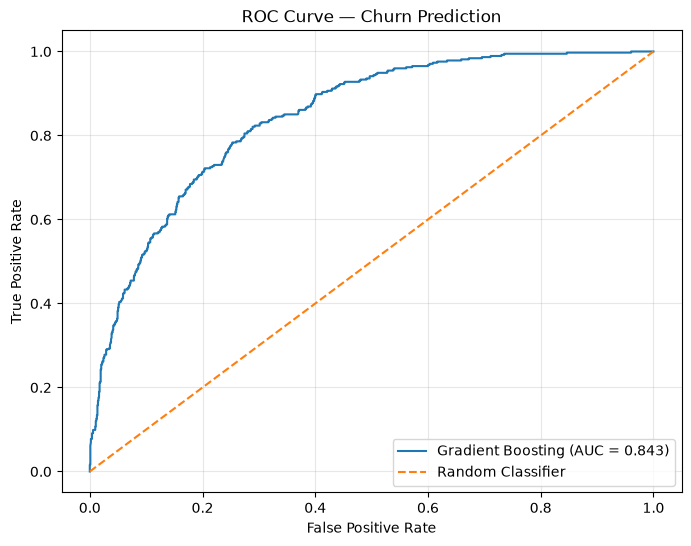

In [74]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    best_model_probabilities
)

print("Number of ROC thresholds:", len(thresholds))

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {best_model_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Churn Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Average Precision: 0.6598


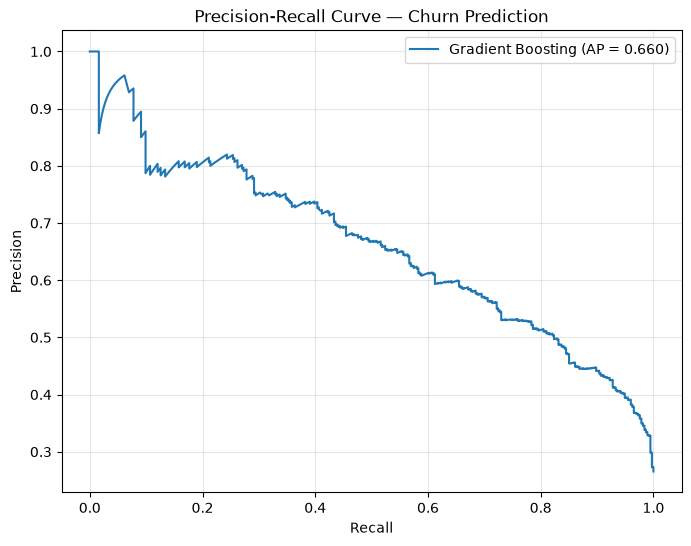

In [75]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    best_model_probabilities
)

average_precision = average_precision_score(
    y_test,
    best_model_probabilities
)

print(
    f"Average Precision: {average_precision:.4f}"
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"{best_model_name} (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Churn Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [76]:
threshold_values = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

threshold_results = []

for threshold in threshold_values:
    
    threshold_predictions = (
        best_model_probabilities >= threshold
    ).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "Customers Flagged": threshold_predictions.sum()
    })

threshold_analysis = pd.DataFrame(
    threshold_results
)

display(threshold_analysis)

,Threshold,Precision,Recall,F1-Score,Customers Flagged
0,0.3,0.530189,0.751337,0.621681,530
1,0.4,0.596535,0.644385,0.619537,404
2,0.5,0.665517,0.516043,0.581325,290
3,0.6,0.730159,0.368984,0.490231,189
4,0.7,0.817391,0.251337,0.384458,115


In [77]:
best_f1_threshold_row = threshold_analysis.loc[
    threshold_analysis["F1-Score"].idxmax()
]

print(
    "Best tested threshold by F1-score:",
    best_f1_threshold_row["Threshold"]
)

print(
    "F1-score:",
    best_f1_threshold_row["F1-Score"]
)

print(
    "Precision:",
    best_f1_threshold_row["Precision"]
)

print(
    "Recall:",
    best_f1_threshold_row["Recall"]
)

Best tested threshold by F1-score: 0.3
F1-score: 0.6216814159292036
Precision: 0.530188679245283
Recall: 0.7513368983957219


In [78]:
print(type(best_model).__name__)

GradientBoostingClassifier


In [79]:
if best_model_name == "Gradient Boosting":
    
    feature_importance_df = pd.DataFrame({
        "Feature": ml_feature_names,
        "Importance": best_model.feature_importances_
    })
    
    feature_importance_df = feature_importance_df.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)
    
    display(feature_importance_df.head(20))

,Feature,Importance
0,categorical__Contract_Month-to-month,0.379621
1,remainder__tenure,0.141978
2,remainder__TotalCharges,0.086804
3,categorical__InternetService_Fiber optic,0.085674
4,remainder__MonthlyCharges,0.079820
5,categorical__OnlineSecurity_No,0.067887
6,categorical__PaymentMethod_Electronic check,0.044142
7,categorical__TechSupport_No,0.037832
8,categorical__PaperlessBilling_No,0.012783
9,categorical__MultipleLines_No,0.011867


In [80]:
if best_model_name == "Logistic Regression":
    
    interpretability_table = feature_importance_df[
        ["Feature", "Coefficient", "Absolute Coefficient"]
    ].copy()

else:
    
    interpretability_table = feature_importance_df[
        ["Feature", "Importance"]
    ].copy()

display(
    interpretability_table.head(20)
)

,Feature,Importance
0,categorical__Contract_Month-to-month,0.379621
1,remainder__tenure,0.141978
2,remainder__TotalCharges,0.086804
3,categorical__InternetService_Fiber optic,0.085674
4,remainder__MonthlyCharges,0.079820
5,categorical__OnlineSecurity_No,0.067887
6,categorical__PaymentMethod_Electronic check,0.044142
7,categorical__TechSupport_No,0.037832
8,categorical__PaperlessBilling_No,0.012783
9,categorical__MultipleLines_No,0.011867


In [81]:
final_model_benchmark = pd.DataFrame({
    "Model": [
        "Majority-Class Baseline",
        best_model_name
    ],
    "Accuracy": [
        majority_accuracy,
        best_model_accuracy
    ],
    "Precision": [
        None,
        best_model_precision
    ],
    "Recall": [
        None,
        best_model_recall
    ],
    "F1-Score": [
        None,
        best_model_f1
    ],
    "ROC-AUC": [
        None,
        best_model_roc_auc
    ]
})

display(final_model_benchmark)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Majority-Class Baseline,0.734564,NaN,NaN,NaN,NaN
1,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843301


In [82]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision",
        "Default Threshold",
        "F1-Optimal Tested Threshold"
    ],
    "Result": [
        best_model_name,
        round(best_model_accuracy, 4),
        round(best_model_precision, 4),
        round(best_model_recall, 4),
        round(best_model_f1, 4),
        round(best_model_roc_auc, 4),
        round(average_precision, 4),
        0.50,
        best_f1_threshold_row["Threshold"]
    ]
})

display(evaluation_summary)

,Metric,Result
0,Model,Gradient Boosting
1,Accuracy,0.8027
2,Precision,0.6655
3,Recall,0.516
4,F1-Score,0.5813
5,ROC-AUC,0.8433
6,Average Precision,0.6598
7,Default Threshold,0.5
8,F1-Optimal Tested Threshold,0.3


## Detailed Model Evaluation

### Objective
Evaluate the leading churn model in greater detail beyond basic model
comparison.

### Evaluation
The selected model was evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

### Curves
ROC and Precision-Recall curves were used to evaluate model discrimination
and the precision-recall trade-off across classification thresholds.

### Threshold Analysis
Multiple probability thresholds were tested to understand how changing
the threshold affects precision, recall, F1-score and the number of
customers flagged for potential intervention.

### Business Relevance
False negatives represent potentially missed churners, while false
positives represent potentially unnecessary retention interventions.

Threshold selection should therefore consider business intervention
capacity and costs rather than relying only on the default 0.50 threshold.

### Outcome
The leading model was evaluated from both predictive and
business-oriented perspectives and is ready for customer-level
risk scoring.

## Customer Risk Scoring

In [83]:
customer_risk = X_test.copy()

customer_risk["Actual_Churn"] = y_test

customer_risk["Churn_Probability"] = best_model_probabilities

customer_risk = customer_risk.sort_values(
    by="Churn_Probability",
    ascending=False
).reset_index(drop=True)

display(
    customer_risk[
        [
            "Churn_Probability",
            "Actual_Churn",
            "Contract",
            "tenure",
            "MonthlyCharges",
            "PaymentMethod"
        ]
    ].head(20)
)

,Churn_Probability,Actual_Churn,Contract,tenure,MonthlyCharges,PaymentMethod
0,0.923953,1,Month-to-month,1,76.45,Electronic check
1,0.918131,1,Month-to-month,1,95.10,Electronic check
2,0.915419,1,Month-to-month,1,77.15,Electronic check
3,0.909008,1,Month-to-month,1,95.45,Electronic check
4,0.902046,1,Month-to-month,1,85.05,Electronic check
5,0.897314,1,Month-to-month,1,79.35,Bank transfer (automatic)
6,0.897224,0,Month-to-month,1,79.15,Mailed check
7,0.893721,1,Month-to-month,1,80.05,Mailed check
8,0.889190,1,Month-to-month,1,79.50,Electronic check
9,0.886516,1,Month-to-month,7,99.25,Electronic check


In [84]:
def assign_risk_category(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    elif probability < 0.80:
        return "High Risk"
    else:
        return "Very High Risk"


customer_risk["Risk_Category"] = (
    customer_risk["Churn_Probability"]
    .apply(assign_risk_category)
)

display(
    customer_risk[
        [
            "Churn_Probability",
            "Risk_Category",
            "Contract",
            "tenure",
            "MonthlyCharges",
            "PaymentMethod"
        ]
    ].head(20)
)

,Churn_Probability,Risk_Category,Contract,tenure,MonthlyCharges,PaymentMethod
0,0.923953,Very High Risk,Month-to-month,1,76.45,Electronic check
1,0.918131,Very High Risk,Month-to-month,1,95.10,Electronic check
2,0.915419,Very High Risk,Month-to-month,1,77.15,Electronic check
3,0.909008,Very High Risk,Month-to-month,1,95.45,Electronic check
4,0.902046,Very High Risk,Month-to-month,1,85.05,Electronic check
5,0.897314,Very High Risk,Month-to-month,1,79.35,Bank transfer (automatic)
6,0.897224,Very High Risk,Month-to-month,1,79.15,Mailed check
7,0.893721,Very High Risk,Month-to-month,1,80.05,Mailed check
8,0.889190,Very High Risk,Month-to-month,1,79.50,Electronic check
9,0.886516,Very High Risk,Month-to-month,7,99.25,Electronic check


In [85]:
risk_distribution = (
    customer_risk["Risk_Category"]
    .value_counts()
    .reindex(
        [
            "Low Risk",
            "Medium Risk",
            "High Risk",
            "Very High Risk"
        ],
        fill_value=0
    )
    .reset_index()
)

risk_distribution.columns = [
    "Risk Category",
    "Customer Count"
]

risk_distribution["Percentage"] = (
    risk_distribution["Customer Count"]
    / len(customer_risk)
    * 100
)

display(risk_distribution)

,Risk Category,Customer Count,Percentage
0,Low Risk,879,62.384670
1,Medium Risk,341,24.201561
2,High Risk,128,9.084457
3,Very High Risk,61,4.329312


In [86]:
highest_risk_customers = customer_risk[
    customer_risk["Risk_Category"].isin(
        ["High Risk", "Very High Risk"]
    )
].copy()

print(
    "High and Very High Risk Customers:",
    len(highest_risk_customers)
)

display(
    highest_risk_customers[
        [
            "Churn_Probability",
            "Risk_Category",
            "Contract",
            "tenure",
            "MonthlyCharges",
            "PaymentMethod",
            "InternetService",
            "OnlineSecurity",
            "TechSupport"
        ]
    ].head(20)
)

High and Very High Risk Customers: 189


,Churn_Probability,Risk_Category,Contract,tenure,MonthlyCharges,PaymentMethod,InternetService,OnlineSecurity,TechSupport
0,0.923953,Very High Risk,Month-to-month,1,76.45,Electronic check,Fiber optic,No,No
1,0.918131,Very High Risk,Month-to-month,1,95.10,Electronic check,Fiber optic,No,No
2,0.915419,Very High Risk,Month-to-month,1,77.15,Electronic check,Fiber optic,No,No
3,0.909008,Very High Risk,Month-to-month,1,95.45,Electronic check,Fiber optic,No,No
4,0.902046,Very High Risk,Month-to-month,1,85.05,Electronic check,Fiber optic,No,No
5,0.897314,Very High Risk,Month-to-month,1,79.35,Bank transfer (automatic),Fiber optic,No,No
6,0.897224,Very High Risk,Month-to-month,1,79.15,Mailed check,Fiber optic,No,No
7,0.893721,Very High Risk,Month-to-month,1,80.05,Mailed check,Fiber optic,No,No
8,0.889190,Very High Risk,Month-to-month,1,79.50,Electronic check,Fiber optic,No,No
9,0.886516,Very High Risk,Month-to-month,7,99.25,Electronic check,Fiber optic,No,No


In [87]:
high_risk_summary = pd.DataFrame({
    "Metric": [
        "High & Very High Risk Customers",
        "Total Monthly Charges",
        "Average Monthly Charges",
        "Average Churn Probability"
    ],
    "Value": [
        len(highest_risk_customers),
        highest_risk_customers["MonthlyCharges"].sum(),
        highest_risk_customers["MonthlyCharges"].mean(),
        highest_risk_customers["Churn_Probability"].mean()
    ]
})

display(high_risk_summary)

,Metric,Value
0,High & Very High Risk Customers,189.000000
1,Total Monthly Charges,14978.600000
2,Average Monthly Charges,79.251852
3,Average Churn Probability,0.740081


In [88]:
risk_exposure_summary = (
    customer_risk
    .groupby("Risk_Category", observed=False)
    .agg(
        Customer_Count=("Risk_Category", "size"),
        Total_Monthly_Charges=("MonthlyCharges", "sum"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
    .reindex(
        [
            "Low Risk",
            "Medium Risk",
            "High Risk",
            "Very High Risk"
        ]
    )
    .reset_index()
)

display(risk_exposure_summary)

,Risk_Category,Customer_Count,Total_Monthly_Charges,Average_Monthly_Charges,Average_Churn_Probability
0,Low Risk,879,50823.3,57.819454,0.094736
1,Medium Risk,341,24499.3,71.845455,0.442055
2,High Risk,128,9925.6,77.543750,0.687434
3,Very High Risk,61,5053.0,82.836066,0.850554


In [89]:
customer_risk["Charge_Score"] = (
    customer_risk["MonthlyCharges"]
    / customer_risk["MonthlyCharges"].max()
)

customer_risk["Priority_Score"] = (
    0.70 * customer_risk["Churn_Probability"]
    + 0.30 * customer_risk["Charge_Score"]
)

customer_risk = customer_risk.sort_values(
    by="Priority_Score",
    ascending=False
).reset_index(drop=True)

display(
    customer_risk[
        [
            "Churn_Probability",
            "MonthlyCharges",
            "Charge_Score",
            "Priority_Score",
            "Risk_Category",
            "Contract",
            "tenure",
            "PaymentMethod"
        ]
    ].head(20)
)

,Churn_Probability,MonthlyCharges,Charge_Score,Priority_Score,Risk_Category,Contract,tenure,PaymentMethod
0,0.918131,95.10,0.814212,0.886956,Very High Risk,Month-to-month,1,Electronic check
1,0.909008,95.45,0.817209,0.881468,Very High Risk,Month-to-month,1,Electronic check
2,0.878725,102.45,0.877140,0.878250,Very High Risk,Month-to-month,1,Electronic check
3,0.886516,99.25,0.849743,0.875484,Very High Risk,Month-to-month,7,Electronic check
4,0.876911,100.95,0.864298,0.873127,Very High Risk,Month-to-month,3,Electronic check
5,0.861387,101.95,0.872860,0.864829,Very High Risk,Month-to-month,7,Electronic check
6,0.869480,96.60,0.827055,0.856753,Very High Risk,Month-to-month,3,Electronic check
7,0.860853,98.05,0.839469,0.854438,Very High Risk,Month-to-month,7,Bank transfer (automatic)
8,0.873341,94.20,0.806507,0.853291,Very High Risk,Month-to-month,2,Bank transfer (automatic)
9,0.902046,85.05,0.728168,0.849882,Very High Risk,Month-to-month,1,Electronic check


In [90]:
def assign_priority_group(score):
    if score >= 0.70:
        return "Priority 1"
    elif score >= 0.50:
        return "Priority 2"
    else:
        return "Priority 3"


customer_risk["Priority_Group"] = (
    customer_risk["Priority_Score"]
    .apply(assign_priority_group)
)

display(
    customer_risk[
        [
            "Priority_Score",
            "Priority_Group",
            "Churn_Probability",
            "Risk_Category",
            "MonthlyCharges",
            "Contract",
            "tenure"
        ]
    ].head(20)
)

,Priority_Score,Priority_Group,Churn_Probability,Risk_Category,MonthlyCharges,Contract,tenure
0,0.886956,Priority 1,0.918131,Very High Risk,95.10,Month-to-month,1
1,0.881468,Priority 1,0.909008,Very High Risk,95.45,Month-to-month,1
2,0.878250,Priority 1,0.878725,Very High Risk,102.45,Month-to-month,1
3,0.875484,Priority 1,0.886516,Very High Risk,99.25,Month-to-month,7
4,0.873127,Priority 1,0.876911,Very High Risk,100.95,Month-to-month,3
5,0.864829,Priority 1,0.861387,Very High Risk,101.95,Month-to-month,7
6,0.856753,Priority 1,0.869480,Very High Risk,96.60,Month-to-month,3
7,0.854438,Priority 1,0.860853,Very High Risk,98.05,Month-to-month,7
8,0.853291,Priority 1,0.873341,Very High Risk,94.20,Month-to-month,2
9,0.849882,Priority 1,0.902046,Very High Risk,85.05,Month-to-month,1


In [91]:
priority_summary = (
    customer_risk
    .groupby("Priority_Group", observed=False)
    .agg(
        Customer_Count=("Priority_Group", "size"),
        Total_Monthly_Charges=("MonthlyCharges", "sum"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
    .reindex(
        [
            "Priority 1",
            "Priority 2",
            "Priority 3"
        ]
    )
    .reset_index()
)

display(priority_summary)

,Priority_Group,Customer_Count,Total_Monthly_Charges,Average_Monthly_Charges,Average_Churn_Probability
0,Priority 1,117,10080.40,86.157265,0.789997
1,Priority 2,245,19942.65,81.398571,0.543101
2,Priority 3,1047,60278.15,57.572254,0.141738


In [92]:
customer_risk_final = customer_risk[
    [
        "Churn_Probability",
        "Risk_Category",
        "Priority_Score",
        "Priority_Group",
        "Actual_Churn",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "PaymentMethod",
        "InternetService",
        "OnlineSecurity",
        "TechSupport",
        "Partner",
        "Dependents"
    ]
].copy()

display(customer_risk_final.head(20))

,Churn_Probability,Risk_Category,Priority_Score,Priority_Group,Actual_Churn,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,OnlineSecurity,TechSupport,Partner,Dependents
0,0.918131,Very High Risk,0.886956,Priority 1,1,1,95.10,95.10,Month-to-month,Electronic check,Fiber optic,No,No,Yes,No
1,0.909008,Very High Risk,0.881468,Priority 1,1,1,95.45,95.45,Month-to-month,Electronic check,Fiber optic,No,No,No,No
2,0.878725,Very High Risk,0.878250,Priority 1,1,1,102.45,102.45,Month-to-month,Electronic check,Fiber optic,Yes,No,Yes,Yes
3,0.886516,Very High Risk,0.875484,Priority 1,1,7,99.25,665.45,Month-to-month,Electronic check,Fiber optic,No,No,Yes,No
4,0.876911,Very High Risk,0.873127,Priority 1,1,3,100.95,329.95,Month-to-month,Electronic check,Fiber optic,No,No,No,No
5,0.861387,Very High Risk,0.864829,Priority 1,1,7,101.95,700.85,Month-to-month,Electronic check,Fiber optic,No,No,Yes,No
6,0.869480,Very High Risk,0.856753,Priority 1,1,3,96.60,291.90,Month-to-month,Electronic check,Fiber optic,No,No,No,No
7,0.860853,Very High Risk,0.854438,Priority 1,1,7,98.05,713.00,Month-to-month,Bank transfer (automatic),Fiber optic,No,No,No,No
8,0.873341,Very High Risk,0.853291,Priority 1,1,2,94.20,193.80,Month-to-month,Bank transfer (automatic),Fiber optic,No,No,No,Yes
9,0.902046,Very High Risk,0.849882,Priority 1,1,1,85.05,85.05,Month-to-month,Electronic check,Fiber optic,No,No,No,No


## Customer Risk Scoring & Prioritization

### Customer Risk Scoring
Predicted churn probabilities were assigned to individual customers in
the held-out test dataset.

### Priority Scoring
A weighted priority score combined:
- Predicted churn probability
- Monthly charge exposure

Churn probability received greater weight because churn risk is the
primary objective of the model.

### Business Relevance
The analysis moves beyond model accuracy to identify customers who may
deserve greater retention attention based on both predicted churn risk
and financial exposure.

### Outcome
A customer-level risk and prioritization dataset was created for
subsequent business analysis, revenue-at-risk assessment and dashboarding.

## Revenue-at-Risk Analysis

In [93]:
revenue_risk_summary = (
    customer_risk
    .groupby("Risk_Category", observed=False)
    .agg(
        Customer_Count=("Risk_Category", "size"),
        Total_Monthly_Charges=("MonthlyCharges", "sum"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
    .reindex(
        [
            "Low Risk",
            "Medium Risk",
            "High Risk",
            "Very High Risk"
        ]
    )
    .reset_index()
)

display(revenue_risk_summary)

,Risk_Category,Customer_Count,Total_Monthly_Charges,Average_Monthly_Charges,Average_Churn_Probability
0,Low Risk,879,50823.3,57.819454,0.094736
1,Medium Risk,341,24499.3,71.845455,0.442055
2,High Risk,128,9925.6,77.543750,0.687434
3,Very High Risk,61,5053.0,82.836066,0.850554


In [94]:
total_monthly_charges_test = (
    customer_risk["MonthlyCharges"].sum()
)

print(
    "Total Monthly Charges in Test Set:",
    round(total_monthly_charges_test, 2)
)

Total Monthly Charges in Test Set: 90301.2


In [95]:
high_risk_revenue = customer_risk[
    customer_risk["Risk_Category"].isin(
        ["High Risk", "Very High Risk"]
    )
].copy()

high_risk_monthly_charges = (
    high_risk_revenue["MonthlyCharges"].sum()
)

high_risk_charge_percentage = (
    high_risk_monthly_charges
    / total_monthly_charges_test
    * 100
)

print(
    "High & Very High Risk Customers:",
    len(high_risk_revenue)
)

print(
    "Monthly Charges at Risk:",
    round(high_risk_monthly_charges, 2)
)

print(
    "Percentage of Test-Set Monthly Charges:",
    round(high_risk_charge_percentage, 2),
    "%"
)

High & Very High Risk Customers: 189
Monthly Charges at Risk: 14978.6
Percentage of Test-Set Monthly Charges: 16.59 %


In [96]:
risk_financial_comparison = (
    customer_risk
    .groupby("Risk_Category", observed=False)
    .agg(
        Customers=("Risk_Category", "size"),
        Monthly_Charges_at_Risk=("MonthlyCharges", "sum"),
        Avg_Monthly_Charges=("MonthlyCharges", "mean"),
        Avg_Churn_Probability=("Churn_Probability", "mean")
    )
    .reindex(
        [
            "Low Risk",
            "Medium Risk",
            "High Risk",
            "Very High Risk"
        ]
    )
    .reset_index()
)

risk_financial_comparison[
    "Charge_Exposure_%"
] = (
    risk_financial_comparison["Monthly_Charges_at_Risk"]
    / total_monthly_charges_test
    * 100
)

display(risk_financial_comparison)

,Risk_Category,Customers,Monthly_Charges_at_Risk,Avg_Monthly_Charges,Avg_Churn_Probability,Charge_Exposure_%
0,Low Risk,879,50823.3,57.819454,0.094736,56.281976
1,Medium Risk,341,24499.3,71.845455,0.442055,27.130647
2,High Risk,128,9925.6,77.543750,0.687434,10.991659
3,Very High Risk,61,5053.0,82.836066,0.850554,5.595717


In [97]:
contract_risk_revenue = (
    high_risk_revenue
    .groupby("Contract", observed=False)
    .agg(
        Customer_Count=("Contract", "size"),
        Monthly_Charges_at_Risk=("MonthlyCharges", "sum"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
    .sort_values(
        by="Monthly_Charges_at_Risk",
        ascending=False
    )
    .reset_index()
)

display(contract_risk_revenue)

,Contract,Customer_Count,Monthly_Charges_at_Risk,Average_Monthly_Charges,Average_Churn_Probability
0,Month-to-month,189,14978.6,79.251852,0.740081


In [98]:
payment_risk_revenue = (
    high_risk_revenue
    .groupby("PaymentMethod", observed=False)
    .agg(
        Customer_Count=("PaymentMethod", "size"),
        Monthly_Charges_at_Risk=("MonthlyCharges", "sum"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
    .sort_values(
        by="Monthly_Charges_at_Risk",
        ascending=False
    )
    .reset_index()
)

display(payment_risk_revenue)

,PaymentMethod,Customer_Count,Monthly_Charges_at_Risk,Average_Monthly_Charges,Average_Churn_Probability
0,Electronic check,144,11224.20,77.945833,0.740544
1,Mailed check,20,1533.95,76.697500,0.724168
2,Credit card (automatic),14,1269.00,90.642857,0.744390
3,Bank transfer (automatic),11,951.45,86.495455,0.757479


In [99]:
top_priority_customers = customer_risk.sort_values(
    by="Priority_Score",
    ascending=False
).head(20)

display(
    top_priority_customers[
        [
            "Priority_Score",
            "Churn_Probability",
            "Risk_Category",
            "Priority_Group",
            "MonthlyCharges",
            "TotalCharges",
            "Contract",
            "tenure",
            "PaymentMethod",
            "InternetService",
            "OnlineSecurity",
            "TechSupport"
        ]
    ]
)

,Priority_Score,Churn_Probability,Risk_Category,Priority_Group,MonthlyCharges,TotalCharges,Contract,tenure,PaymentMethod,InternetService,OnlineSecurity,TechSupport
0,0.886956,0.918131,Very High Risk,Priority 1,95.10,95.10,Month-to-month,1,Electronic check,Fiber optic,No,No
1,0.881468,0.909008,Very High Risk,Priority 1,95.45,95.45,Month-to-month,1,Electronic check,Fiber optic,No,No
2,0.878250,0.878725,Very High Risk,Priority 1,102.45,102.45,Month-to-month,1,Electronic check,Fiber optic,Yes,No
3,0.875484,0.886516,Very High Risk,Priority 1,99.25,665.45,Month-to-month,7,Electronic check,Fiber optic,No,No
4,0.873127,0.876911,Very High Risk,Priority 1,100.95,329.95,Month-to-month,3,Electronic check,Fiber optic,No,No
5,0.864829,0.861387,Very High Risk,Priority 1,101.95,700.85,Month-to-month,7,Electronic check,Fiber optic,No,No
6,0.856753,0.869480,Very High Risk,Priority 1,96.60,291.90,Month-to-month,3,Electronic check,Fiber optic,No,No
7,0.854438,0.860853,Very High Risk,Priority 1,98.05,713.00,Month-to-month,7,Bank transfer (automatic),Fiber optic,No,No
8,0.853291,0.873341,Very High Risk,Priority 1,94.20,193.80,Month-to-month,2,Bank transfer (automatic),Fiber optic,No,No
9,0.849882,0.902046,Very High Risk,Priority 1,85.05,85.05,Month-to-month,1,Electronic check,Fiber optic,No,No


In [100]:
revenue_at_risk_kpis = pd.DataFrame({
    "KPI": [
        "Test Set Customers",
        "Total Monthly Charges",
        "High & Very High Risk Customers",
        "Monthly Charges at Risk",
        "Percentage of Monthly Charges at Risk"
    ],
    "Value": [
        len(customer_risk),
        round(total_monthly_charges_test, 2),
        len(high_risk_revenue),
        round(high_risk_monthly_charges, 2),
        round(high_risk_charge_percentage, 2)
    ]
})

display(revenue_at_risk_kpis)

,KPI,Value
0,Test Set Customers,1409.00
1,Total Monthly Charges,90301.20
2,High & Very High Risk Customers,189.00
3,Monthly Charges at Risk,14978.60
4,Percentage of Monthly Charges at Risk,16.59


## Revenue-at-Risk Analysis

### Objective
Connect customer churn risk with financial exposure to support
business-oriented retention prioritization.

### Financial Measure
`MonthlyCharges` was used as the available measure of monthly
customer charge exposure.

### High-Risk Exposure
Customers classified as High or Very High Risk were analyzed to
estimate the monthly charges associated with the identified
risk population.

### Segment Analysis
Financial exposure was further examined across:
- Contract type
- Payment method

This provides context for where high-risk financial exposure is
concentrated.

### Customer Prioritization
The customer-level priority score created in previous section was used
to identify customers combining relatively high churn probability
with higher monthly charge exposure.

### Business Relevance
Revenue-at-risk analysis helps move churn prediction from a purely
technical exercise toward practical retention prioritization.

### Outcome
A financial-risk view was created to connect predicted churn,
customer segments and monthly charge exposure for downstream
business analysis and dashboarding.

## Final Customer Scoring & Full-Dataset Risk Profiling

In [101]:
X_full = X.copy()

print("Full feature dataset shape:", X_full.shape)
print("Number of features:", X_full.shape[1])

Full feature dataset shape: (7043, 19)
Number of features: 19


In [102]:
X_full_processed = preprocessor_ml.transform(
    X_full
)

print(
    "Processed full dataset shape:",
    X_full_processed.shape
)

Processed full dataset shape: (7043, 45)


In [103]:
full_churn_probabilities = best_model.predict_proba(
    X_full_processed
)[:, 1]

print(
    "Number of customer probabilities:",
    len(full_churn_probabilities)
)

print(
    "Minimum probability:",
    round(full_churn_probabilities.min(), 4)
)

print(
    "Maximum probability:",
    round(full_churn_probabilities.max(), 4)
)

print(
    "Average probability:",
    round(full_churn_probabilities.mean(), 4)
)

Number of customer probabilities: 7043
Minimum probability: 0.0084
Maximum probability: 0.9428
Average probability: 0.2654


In [104]:
full_customer_risk = X_full.copy()

full_customer_risk["Churn_Probability"] = (
    full_churn_probabilities
)

display(
    full_customer_risk[
        [
            "Churn_Probability",
            "Contract",
            "tenure",
            "MonthlyCharges",
            "PaymentMethod"
        ]
    ].head(20)
)

,Churn_Probability,Contract,tenure,MonthlyCharges,PaymentMethod
0,0.486477,Month-to-month,1,29.85,Electronic check
1,0.046527,One year,34,56.95,Mailed check
2,0.345867,Month-to-month,2,53.85,Mailed check
3,0.044496,One year,45,42.30,Bank transfer (automatic)
4,0.639668,Month-to-month,2,70.70,Electronic check
5,0.880773,Month-to-month,8,99.65,Electronic check
6,0.412910,Month-to-month,22,89.10,Credit card (automatic)
7,0.126893,Month-to-month,10,29.75,Mailed check
8,0.688943,Month-to-month,28,104.80,Electronic check
9,0.043065,One year,62,56.15,Bank transfer (automatic)


In [105]:
full_customer_risk["Risk_Category"] = (
    full_customer_risk["Churn_Probability"]
    .apply(assign_risk_category)
)

display(
    full_customer_risk[
        [
            "Churn_Probability",
            "Risk_Category",
            "Contract",
            "tenure",
            "MonthlyCharges",
            "PaymentMethod"
        ]
    ].head(20)
)

,Churn_Probability,Risk_Category,Contract,tenure,MonthlyCharges,PaymentMethod
0,0.486477,Medium Risk,Month-to-month,1,29.85,Electronic check
1,0.046527,Low Risk,One year,34,56.95,Mailed check
2,0.345867,Medium Risk,Month-to-month,2,53.85,Mailed check
3,0.044496,Low Risk,One year,45,42.30,Bank transfer (automatic)
4,0.639668,High Risk,Month-to-month,2,70.70,Electronic check
5,0.880773,Very High Risk,Month-to-month,8,99.65,Electronic check
6,0.412910,Medium Risk,Month-to-month,22,89.10,Credit card (automatic)
7,0.126893,Low Risk,Month-to-month,10,29.75,Mailed check
8,0.688943,High Risk,Month-to-month,28,104.80,Electronic check
9,0.043065,Low Risk,One year,62,56.15,Bank transfer (automatic)


In [106]:
full_customer_risk["Charge_Score"] = (
    full_customer_risk["MonthlyCharges"]
    / full_customer_risk["MonthlyCharges"].max()
)

In [107]:
full_customer_risk["Priority_Score"] = (
    0.70 * full_customer_risk["Churn_Probability"]
    + 0.30 * full_customer_risk["Charge_Score"]
)

In [108]:
full_customer_risk["Priority_Group"] = (
    full_customer_risk["Priority_Score"]
    .apply(assign_priority_group)
)

In [109]:
full_risk_distribution = (
    full_customer_risk["Risk_Category"]
    .value_counts()
    .reindex(
        [
            "Low Risk",
            "Medium Risk",
            "High Risk",
            "Very High Risk"
        ],
        fill_value=0
    )
    .reset_index()
)

full_risk_distribution.columns = [
    "Risk Category",
    "Customer Count"
]

full_risk_distribution["Percentage"] = (
    full_risk_distribution["Customer Count"]
    / len(full_customer_risk)
    * 100
)

display(full_risk_distribution)

,Risk Category,Customer Count,Percentage
0,Low Risk,4441,63.055516
1,Medium Risk,1604,22.774386
2,High Risk,706,10.024137
3,Very High Risk,292,4.145961


In [110]:
full_risk_exposure = (
    full_customer_risk
    .groupby("Risk_Category", observed=False)
    .agg(
        Customer_Count=("Risk_Category", "size"),
        Monthly_Charges=("MonthlyCharges", "sum"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
    .reindex(
        [
            "Low Risk",
            "Medium Risk",
            "High Risk",
            "Very High Risk"
        ]
    )
    .reset_index()
)

full_total_monthly_charges = (
    full_customer_risk["MonthlyCharges"].sum()
)

full_risk_exposure["Charge_Exposure_%"] = (
    full_risk_exposure["Monthly_Charges"]
    / full_total_monthly_charges
    * 100
)

display(full_risk_exposure)

,Risk_Category,Customer_Count,Monthly_Charges,Average_Monthly_Charges,Average_Churn_Probability,Charge_Exposure_%
0,Low Risk,4441,259745.80,58.488133,0.096860,56.947237
1,Medium Risk,1604,116208.65,72.449283,0.438386,25.477838
2,High Risk,706,56108.70,79.474079,0.690632,12.301394
3,Very High Risk,292,24053.45,82.374829,0.850502,5.273531


In [111]:
full_high_risk = full_customer_risk[
    full_customer_risk["Risk_Category"].isin(
        ["High Risk", "Very High Risk"]
    )
].copy()

full_high_risk_customers = len(full_high_risk)

full_high_risk_charges = (
    full_high_risk["MonthlyCharges"].sum()
)

full_high_risk_charge_percentage = (
    full_high_risk_charges
    / full_total_monthly_charges
    * 100
)

full_high_risk_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "High & Very High Risk Customers",
        "High & Very High Risk Percentage",
        "Total Monthly Charges",
        "Monthly Charges Associated with High-Risk Customers",
        "Percentage of Monthly Charges Associated with High-Risk Customers"
    ],
    "Value": [
        len(full_customer_risk),
        full_high_risk_customers,
        round(
            full_high_risk_customers
            / len(full_customer_risk)
            * 100,
            2
        ),
        round(full_total_monthly_charges, 2),
        round(full_high_risk_charges, 2),
        round(full_high_risk_charge_percentage, 2)
    ]
})

display(full_high_risk_summary)

,Metric,Value
0,Total Customers,7043.00
1,High & Very High Risk Customers,998.00
2,High & Very High Risk Percentage,14.17
3,Total Monthly Charges,456116.60
4,Monthly Charges Associated with High-Risk Cust...,80162.15
5,Percentage of Monthly Charges Associated with ...,17.57


In [112]:
full_top_priority_customers = (
    full_customer_risk
    .sort_values(
        by="Priority_Score",
        ascending=False
    )
    .head(50)
    .copy()
)

display(
    full_top_priority_customers[
        [
            "Priority_Score",
            "Churn_Probability",
            "Risk_Category",
            "Priority_Group",
            "MonthlyCharges",
            "TotalCharges",
            "Contract",
            "tenure",
            "PaymentMethod",
            "InternetService",
            "OnlineSecurity",
            "TechSupport"
        ]
    ]
)

,Priority_Score,Churn_Probability,Risk_Category,Priority_Group,MonthlyCharges,TotalCharges,Contract,tenure,PaymentMethod,InternetService,OnlineSecurity,TechSupport
2208,0.914605,0.942789,Very High Risk,Priority 1,100.80,100.80,Month-to-month,1,Electronic check,Fiber optic,No,No
6482,0.907148,0.929790,Very High Risk,Priority 1,101.45,101.45,Month-to-month,1,Electronic check,Fiber optic,No,No
1704,0.904161,0.931658,Very High Risk,Priority 1,99.75,99.75,Month-to-month,1,Electronic check,Fiber optic,No,No
4459,0.890672,0.910585,Very High Risk,Priority 1,100.25,100.25,Month-to-month,1,Credit card (automatic),Fiber optic,No,No
2577,0.887542,0.926503,Very High Risk,Priority 1,94.60,94.60,Month-to-month,1,Electronic check,Fiber optic,No,No
4800,0.886626,0.927360,Very High Risk,Priority 1,94.00,94.00,Month-to-month,1,Electronic check,Fiber optic,No,No
3209,0.885647,0.926503,Very High Risk,Priority 1,93.85,93.85,Month-to-month,1,Electronic check,Fiber optic,No,No
1976,0.885489,0.927360,Very High Risk,Priority 1,93.55,93.55,Month-to-month,1,Electronic check,Fiber optic,No,No
3380,0.882944,0.918131,Very High Risk,Priority 1,95.10,95.10,Month-to-month,1,Electronic check,Fiber optic,No,No
6866,0.877442,0.909008,Very High Risk,Priority 1,95.45,95.45,Month-to-month,1,Electronic check,Fiber optic,No,No


In [113]:
customer_scoring_final = full_customer_risk[
    [
        "Churn_Probability",
        "Risk_Category",
        "Charge_Score",
        "Priority_Score",
        "Priority_Group",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "PaymentMethod",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Partner",
        "Dependents"
    ]
].copy()

print(
    "Final customer scoring dataset shape:",
    customer_scoring_final.shape
)

display(customer_scoring_final.head(20))

Final customer scoring dataset shape: (7043, 19)


,Churn_Probability,Risk_Category,Charge_Score,Priority_Score,Priority_Group,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Partner,Dependents
0,0.486477,Medium Risk,0.251368,0.415945,Priority 3,1,29.85,29.85,Month-to-month,Electronic check,DSL,No,Yes,No,No,No,No,Yes,No
1,0.046527,Low Risk,0.479579,0.176443,Priority 3,34,56.95,1889.50,One year,Mailed check,DSL,Yes,No,Yes,No,No,No,No,No
2,0.345867,Medium Risk,0.453474,0.378149,Priority 3,2,53.85,108.15,Month-to-month,Mailed check,DSL,Yes,Yes,No,No,No,No,No,No
3,0.044496,Low Risk,0.356211,0.138010,Priority 3,45,42.30,1840.75,One year,Bank transfer (automatic),DSL,Yes,No,Yes,Yes,No,No,No,No
4,0.639668,High Risk,0.595368,0.626378,Priority 2,2,70.70,151.65,Month-to-month,Electronic check,Fiber optic,No,No,No,No,No,No,No,No
5,0.880773,Very High Risk,0.839158,0.868288,Priority 1,8,99.65,820.50,Month-to-month,Electronic check,Fiber optic,No,No,Yes,No,Yes,Yes,No,No
6,0.412910,Medium Risk,0.750316,0.514132,Priority 2,22,89.10,1949.40,Month-to-month,Credit card (automatic),Fiber optic,No,Yes,No,No,Yes,No,No,Yes
7,0.126893,Low Risk,0.250526,0.163983,Priority 3,10,29.75,301.90,Month-to-month,Mailed check,DSL,Yes,No,No,No,No,No,No,No
8,0.688943,High Risk,0.882526,0.747018,Priority 1,28,104.80,3046.05,Month-to-month,Electronic check,Fiber optic,No,No,Yes,Yes,Yes,Yes,Yes,No
9,0.043065,Low Risk,0.472842,0.171998,Priority 3,62,56.15,3487.95,One year,Bank transfer (automatic),DSL,Yes,Yes,No,No,No,No,No,Yes


In [114]:
print("Rows:", len(customer_scoring_final))
print(
    "Missing values:",
    customer_scoring_final.isnull().sum().sum()
)
print(
    "Risk categories:",
    customer_scoring_final["Risk_Category"].unique()
)
print(
    "Priority groups:",
    customer_scoring_final["Priority_Group"].unique()
)
print(
    "Probability range:",
    round(
        customer_scoring_final["Churn_Probability"].min(),
        4
    ),
    "to",
    round(
        customer_scoring_final["Churn_Probability"].max(),
        4
    )
)

Rows: 7043
Missing values: 0
Risk categories: <StringArray>
['Medium Risk', 'Low Risk', 'High Risk', 'Very High Risk']
Length: 4, dtype: str
Priority groups: <StringArray>
['Priority 3', 'Priority 2', 'Priority 1']
Length: 3, dtype: str
Probability range: 0.0084 to 0.9428


## Final Customer Scoring & Full-Dataset Risk Profiling

### Objective
Apply the selected churn model to the available customer population to
create a complete customer-level risk and prioritization dataset.

### Scoring Workflow
The trained preprocessing pipeline was used to transform the full feature
dataset, followed by the selected machine-learning model to generate
customer-level churn probabilities.

### Risk Classification
Customers were classified into:
- Low Risk
- Medium Risk
- High Risk
- Very High Risk

### Financial Exposure
Monthly charges were analyzed across risk categories to estimate the
financial exposure associated with potentially at-risk customers.

### Priority Scoring
A business-oriented priority score combined predicted churn probability
with normalized monthly charge exposure.

### Full-Population Analysis
Risk distribution, customer counts and monthly charge exposure were
analyzed across the available customer population.

### Final Output
A customer-level scoring dataset was created containing:
- Churn probability
- Risk category
- Priority score
- Priority group
- Customer characteristics
- Monthly charge information

### Methodological Principle
The held-out test set remains the primary basis for model performance
evaluation, while full-dataset scoring is used for business-oriented
customer profiling and prioritization.

### Outcome
The machine-learning workflow was extended into a complete customer-level
risk scoring framework suitable for downstream SQL analysis, dashboarding
and business recommendations.

In [115]:
# Export the final full-population customer scoring dataset
scoring_export_path = "../data/processed/customer_scoring_final.csv"

customer_scoring_final.to_csv(
    scoring_export_path,
    index=False
)

print("Customer scoring dataset exported successfully.")
print("Saved to:", scoring_export_path)
print("Shape:", customer_scoring_final.shape)

Customer scoring dataset exported successfully.
Saved to: ../data/processed/customer_scoring_final.csv
Shape: (7043, 19)
